#### Modules

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.trial import TrialState

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')

#### Functions

In [ ]:
# PyTorch Neural Network Model Class
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, n1, d1, n2, d2, output_size=1, activation='elu'):
        super(NeuralNetwork, self).__init__()
        
        # Define activation function
        if activation == 'elu':
            self.activation = nn.ELU()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()
        
        # First layer
        self.fc1 = nn.Linear(input_size, n1)
        self.bn1 = nn.BatchNorm1d(n1)
        self.dropout1 = nn.Dropout(d1)
        
        # Second layer
        self.fc2 = nn.Linear(n1, n2)
        self.bn2 = nn.BatchNorm1d(n2)
        self.dropout2 = nn.Dropout(d2)
        
        # Output layer
        self.fc3 = nn.Linear(n2, output_size)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x


# Training function with early stopping
def train_model(model, train_loader, val_loader, epochs=100, patience=15, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses


# Hyperparameter tuning with Optuna
def tune_hyperparameters(X_train, y_train, activation='elu', n_trials=30):
    def objective(trial):
        # Suggest hyperparameters
        n1 = trial.suggest_int('n1', 32, 256, step=32)
        d1 = trial.suggest_float('d1', 0.1, 0.5, step=0.1)
        n2 = trial.suggest_int('n2', 16, 128, step=16)
        d2 = trial.suggest_float('d2', 0.1, 0.5, step=0.1)
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
        
        # Split training data into train and validation
        X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        # Convert to tensors
        X_tr_tensor = torch.FloatTensor(X_tr).to(device)
        y_tr_tensor = torch.FloatTensor(y_tr.values).reshape(-1, 1).to(device)
        X_val_tensor = torch.FloatTensor(X_val).to(device)
        y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        
        # Create model
        input_size = X_train.shape[1]
        model = NeuralNetwork(input_size, n1, d1, n2, d2, activation=activation).to(device)
        
        # Train model with reduced epochs for tuning
        model, _, val_losses = train_model(model, train_loader, val_loader, epochs=50, patience=10, lr=lr)
        
        return min(val_losses)
    
    # Create study and optimize
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print('\nBest hyperparameters:')
    print(f"  Units Layer 1: {study.best_params['n1']}")
    print(f"  Dropout Layer 1: {study.best_params['d1']}")
    print(f"  Units Layer 2: {study.best_params['n2']}")
    print(f"  Dropout Layer 2: {study.best_params['d2']}")
    print(f"  Learning Rate: {study.best_params['lr']:.6f}")
    print(f"  Batch Size: {study.best_params['batch_size']}")
    print(f"  Best Validation Loss: {study.best_value:.4f}")
    
    return study.best_params


# Model evaluation function
def model_evaluation(model, X_test, y_test, target_name):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        predictions = model(X_test_tensor).cpu().numpy().flatten()
    
    y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
    
    rmse = root_mean_squared_error(y_test_array, predictions)
    r2 = r2_score(y_test_array, predictions)
    
    print(f'RMSE: {rmse:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(predictions, y_test_array, alpha=0.5)
    plt.plot([y_test_array.min(), y_test_array.max()], 
             [y_test_array.min(), y_test_array.max()], 
             'r--', lw=2, label='Perfect Prediction')
    plt.xlabel(f'Predicted {target_name}')
    plt.ylabel(f'Actual {target_name}')
    plt.title(f'{target_name} -- Predicted vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return predictions


# Training history plot
def training_history_plot(train_losses, val_losses, title):
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{title} -- Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#### Initial set up

In [ ]:
# Load dataset
df = pd.read_csv('Use dataset.csv')
x_c = df.drop(columns = ['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'])
city = df['Fuel Consumption City (L/100 km)']
x_h = df.drop(columns = ['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'])
hwy = df['Fuel Consumption Hwy (L/100 km)']

# Split the data into training and testing sets (80% train, 20% test)
xc_train, xc_test, c_tr, c_te = train_test_split(x_c, city, test_size=0.2, random_state=42)
xh_train, xh_test, h_tr, h_te = train_test_split(x_h, hwy, test_size=0.2, random_state=42)

# Standardize X data
scaler_c = StandardScaler()
xc_tr = scaler_c.fit_transform(xc_train)
xc_te = scaler_c.transform(xc_test)

scaler_h = StandardScaler()
xh_tr = scaler_h.fit_transform(xh_train)
xh_te = scaler_h.transform(xh_test)

# Define activation function
AF = 'elu'

print(f'Training set size: {len(xc_tr)} samples')
print(f'Test set size: {len(xc_te)} samples')
print(f'Number of features: {xc_tr.shape[1]}')

#### Neural Network Training by Vehicle Type (Split Architecture)

In [ ]:
# Train separate neural network models for each vehicle Type
print("="*80)
print("NEURAL NETWORK TRAINING BY VEHICLE TYPE")
print("="*80)

# Check if Type column exists
if 'Type' not in df.columns:
    print("\nWARNING: 'Type' column not found in dataset.")
    print("This architecture requires the dataset to have a 'Type' column.")
    print("Please ensure you're using the processed dataset from Phase 2.")
else:
    # Storage for results
    type_results = {}
    
    # Loop through each vehicle type
    for type_val in sorted(df['Type'].unique()):
        print(f"\n{'='*80}")
        print(f"Processing Vehicle Type: {type_val}")
        print(f"{'='*80}")
        
        # Filter data for this type
        df_type = df[df['Type'] == type_val].copy()
        print(f"Samples for Type {type_val}: {len(df_type)}")
        
        # Separate features and targets (exclude Type from features)
        X_type = df_type.drop(columns=['Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'])
        y_city_type = df_type['Fuel Consumption City (L/100 km)']
        y_hwy_type = df_type['Fuel Consumption Hwy (L/100 km)']
        
        # Skip if insufficient samples
        if len(df_type) < 50:
            print(f"Skipping Type {type_val} - insufficient samples (< 50)")
            continue
        
        # Train-test split
        X_train, X_test, y_city_train, y_city_test = train_test_split(
            X_type, y_city_type, test_size=0.2, random_state=42
        )
        _, _, y_hwy_train, y_hwy_test = train_test_split(
            X_type, y_hwy_type, test_size=0.2, random_state=42
        )
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # ===== CITY MODEL =====
        print(f"\n--- Training City Model for Type {type_val} ---")
        
        # Tune hyperparameters (reduced trials for speed)
        best_params_city_type = tune_hyperparameters(
            X_train_scaled, y_city_train, activation=AF, n_trials=10
        )
        
        # Split for validation
        X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(
            X_train_scaled, y_city_train, test_size=0.2, random_state=42
        )
        
        # Convert to tensors
        X_tr_c_tensor = torch.FloatTensor(X_tr_c).to(device)
        y_tr_c_tensor = torch.FloatTensor(y_tr_c.values).reshape(-1, 1).to(device)
        X_val_c_tensor = torch.FloatTensor(X_val_c).to(device)
        y_val_c_tensor = torch.FloatTensor(y_val_c.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset_c = TensorDataset(X_tr_c_tensor, y_tr_c_tensor)
        val_dataset_c = TensorDataset(X_val_c_tensor, y_val_c_tensor)
        train_loader_c = DataLoader(train_dataset_c, batch_size=best_params_city_type['batch_size'], shuffle=True)
        val_loader_c = DataLoader(val_dataset_c, batch_size=best_params_city_type['batch_size'])
        
        # Create and train model
        model_city_type = NeuralNetwork(
            input_size=X_train_scaled.shape[1],
            n1=best_params_city_type['n1'],
            d1=best_params_city_type['d1'],
            n2=best_params_city_type['n2'],
            d2=best_params_city_type['d2'],
            activation=AF
        ).to(device)
        
        model_city_type, train_losses_c, val_losses_c = train_model(
            model_city_type, train_loader_c, val_loader_c, 
            epochs=100, patience=15, lr=best_params_city_type['lr']
        )
        
        # Evaluate on test set
        model_city_type.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
            y_city_pred = model_city_type(X_test_tensor).cpu().numpy().flatten()
        
        c_rmse = root_mean_squared_error(y_city_test, y_city_pred)
        c_r2 = r2_score(y_city_test, y_city_pred)
        print(f"City Model - R²: {c_r2:.4f}, RMSE: {c_rmse:.4f}")
        
        # ===== HIGHWAY MODEL =====
        print(f"\n--- Training Highway Model for Type {type_val} ---")
        
        # Tune hyperparameters
        best_params_hwy_type = tune_hyperparameters(
            X_train_scaled, y_hwy_train, activation=AF, n_trials=10
        )
        
        # Split for validation
        X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(
            X_train_scaled, y_hwy_train, test_size=0.2, random_state=42
        )
        
        # Convert to tensors
        X_tr_h_tensor = torch.FloatTensor(X_tr_h).to(device)
        y_tr_h_tensor = torch.FloatTensor(y_tr_h.values).reshape(-1, 1).to(device)
        X_val_h_tensor = torch.FloatTensor(X_val_h).to(device)
        y_val_h_tensor = torch.FloatTensor(y_val_h.values).reshape(-1, 1).to(device)
        
        # Create data loaders
        train_dataset_h = TensorDataset(X_tr_h_tensor, y_tr_h_tensor)
        val_dataset_h = TensorDataset(X_val_h_tensor, y_val_h_tensor)
        train_loader_h = DataLoader(train_dataset_h, batch_size=best_params_hwy_type['batch_size'], shuffle=True)
        val_loader_h = DataLoader(val_dataset_h, batch_size=best_params_hwy_type['batch_size'])
        
        # Create and train model
        model_hwy_type = NeuralNetwork(
            input_size=X_train_scaled.shape[1],
            n1=best_params_hwy_type['n1'],
            d1=best_params_hwy_type['d1'],
            n2=best_params_hwy_type['n2'],
            d2=best_params_hwy_type['d2'],
            activation=AF
        ).to(device)
        
        model_hwy_type, train_losses_h, val_losses_h = train_model(
            model_hwy_type, train_loader_h, val_loader_h, 
            epochs=100, patience=15, lr=best_params_hwy_type['lr']
        )
        
        # Evaluate on test set
        model_hwy_type.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
            y_hwy_pred = model_hwy_type(X_test_tensor).cpu().numpy().flatten()
        
        h_rmse = root_mean_squared_error(y_hwy_test, y_hwy_pred)
        h_r2 = r2_score(y_hwy_test, y_hwy_pred)
        print(f"Highway Model - R²: {h_r2:.4f}, RMSE: {h_rmse:.4f}")
        
        # Store results
        type_results[type_val] = {
            'city_model': model_city_type,
            'hwy_model': model_hwy_type,
            'city_r2': c_r2,
            'city_rmse': c_rmse,
            'hwy_r2': h_r2,
            'hwy_rmse': h_rmse,
            'city_pred': y_city_pred,
            'city_test': y_city_test,
            'hwy_pred': y_hwy_pred,
            'hwy_test': y_hwy_test,
            'train_losses_city': train_losses_c,
            'val_losses_city': val_losses_c,
            'train_losses_hwy': train_losses_h,
            'val_losses_hwy': val_losses_h,
            'best_params_city': best_params_city_type,
            'best_params_hwy': best_params_hwy_type
        }
    
    print("\n" + "="*80)
    print("TRAINING COMPLETE FOR ALL VEHICLE TYPES")
    print("="*80)

#### Prediction vs Actual Plots by Vehicle Type

In [ ]:
# Plot prediction vs actual for all vehicle types
if 'type_results' in locals() and len(type_results) > 0:
    fig, axes = plt.subplots(len(type_results), 2, figsize=(16, 6*len(type_results)))
    
    # Handle case where there's only one type
    if len(type_results) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (type_val, results) in enumerate(sorted(type_results.items())):
        # City model predictions
        ax1 = axes[idx, 0]
        y_test = results['city_test']
        y_pred = results['city_pred']
        
        ax1.scatter(y_pred, y_test, alpha=0.6, s=30)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        ax1.set_xlabel('Predicted City Fuel Consumption')
        ax1.set_ylabel('Actual City Fuel Consumption')
        ax1.set_title(f'Type {type_val} - City Model\\nR²={results["city_r2"]:.4f}, RMSE={results["city_rmse"]:.4f}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Highway model predictions
        ax2 = axes[idx, 1]
        y_test = results['hwy_test']
        y_pred = results['hwy_pred']
        
        ax2.scatter(y_pred, y_test, alpha=0.6, s=30, color='orange')
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        ax2.set_xlabel('Predicted Highway Fuel Consumption')
        ax2.set_ylabel('Actual Highway Fuel Consumption')
        ax2.set_title(f'Type {type_val} - Highway Model\\nR²={results["hwy_r2"]:.4f}, RMSE={results["hwy_rmse"]:.4f}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available. Please run the training cell first.")

#### Training History by Vehicle Type

In [ ]:
# Plot training history for all vehicle types
if 'type_results' in locals() and len(type_results) > 0:
    fig, axes = plt.subplots(len(type_results), 2, figsize=(16, 5*len(type_results)))
    
    # Handle case where there's only one type
    if len(type_results) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (type_val, results) in enumerate(sorted(type_results.items())):
        # City model training history
        ax1 = axes[idx, 0]
        ax1.plot(results['train_losses_city'], label='Training Loss')
        ax1.plot(results['val_losses_city'], label='Validation Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'Type {type_val} - City Model Training History')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Highway model training history
        ax2 = axes[idx, 1]
        ax2.plot(results['train_losses_hwy'], label='Training Loss', color='orange')
        ax2.plot(results['val_losses_hwy'], label='Validation Loss', color='red')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Loss')
        ax2.set_title(f'Type {type_val} - Highway Model Training History')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available. Please run the training cell first.")

#### Performance Summary by Vehicle Type

#### Neural Network for Fuel Consumption City

In [ ]:
# Hyperparameter tuning for city fuel consumption model
print("Starting hyperparameter tuning for City Fuel Consumption model...")
best_params_city = tune_hyperparameters(xc_tr, c_tr, activation=AF, n_trials=20)

Trial 59 Complete [00h 00m 12s]
val_root_mean_squared_error: 1.1555602550506592

Best val_root_mean_squared_error So Far: 1.0404939651489258
Total elapsed time: 00h 09m 14s

        The hyperparameter search is complete. 
        Optimal Layer 1 Units: 192
        Optimal Layer 1 Dropout: 0.2
        Optimal Layer 2 Units: 128
        Optimal Layer 2 Dropout: 0.1
        
Epoch 1/100


c:\Users\MSI-NB\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 135.5233 - root_mean_squared_error: 11.6414 - val_loss: 111.8534 - val_root_mean_squared_error: 10.5761
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.7542 - root_mean_squared_error: 8.3519 - val_loss: 32.0859 - val_root_mean_squared_error: 5.6644
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.8527 - root_mean_squared_error: 3.7219 - val_loss: 4.2036 - val_root_mean_squared_error: 2.0503
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9257 - root_mean_squared_error: 2.2194 - val_loss: 3.2072 - val_root_mean_squared_error: 1.7909
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.2006 - root_mean_squared_error: 2.0495 - val_loss: 2.9249 - val_root_mean_squared_error: 1.7102
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3169 - root_mean_squared_error: 2.0777 - val_loss: 2.5410 - val_root_mean_squared_error: 1.5940
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE: 1.1670691150476298
R2 Score: 0.8918520342190392


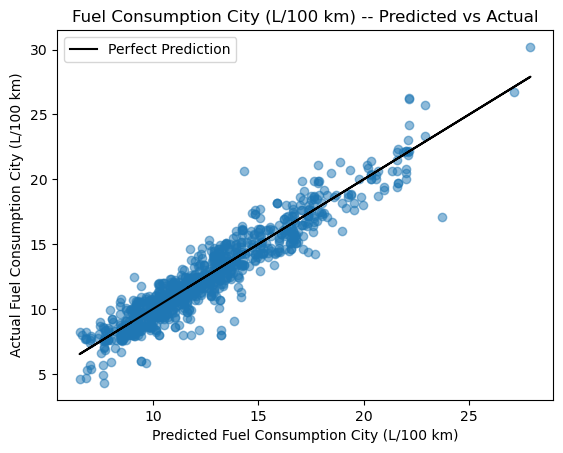

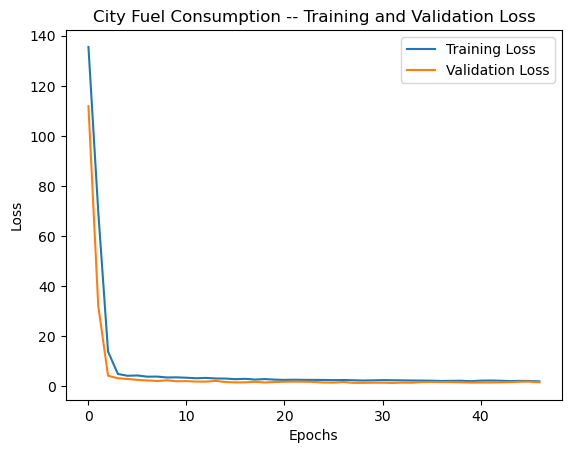

In [ ]:
# Train final model with best hyperparameters
print("\nTraining final City model with best hyperparameters...")

# Split training data for validation
X_c_tr, X_c_val, y_c_tr, y_c_val = train_test_split(xc_tr, c_tr, test_size=0.2, random_state=42)

# Convert to tensors and create data loaders
X_c_tr_tensor = torch.FloatTensor(X_c_tr).to(device)
y_c_tr_tensor = torch.FloatTensor(y_c_tr.values).reshape(-1, 1).to(device)
X_c_val_tensor = torch.FloatTensor(X_c_val).to(device)
y_c_val_tensor = torch.FloatTensor(y_c_val.values).reshape(-1, 1).to(device)

train_dataset_c = TensorDataset(X_c_tr_tensor, y_c_tr_tensor)
val_dataset_c = TensorDataset(X_c_val_tensor, y_c_val_tensor)
train_loader_c = DataLoader(train_dataset_c, batch_size=best_params_city['batch_size'], shuffle=True)
val_loader_c = DataLoader(val_dataset_c, batch_size=best_params_city['batch_size'])

# Create and train model
city_model = NeuralNetwork(
    input_size=xc_tr.shape[1],
    n1=best_params_city['n1'],
    d1=best_params_city['d1'],
    n2=best_params_city['n2'],
    d2=best_params_city['d2'],
    activation=AF
).to(device)

city_model, city_train_losses, city_val_losses = train_model(
    city_model, train_loader_c, val_loader_c, 
    epochs=100, patience=15, lr=best_params_city['lr']
)

print("\nCity Model Training Complete!")

# Plot training history
training_history_plot(city_train_losses, city_val_losses, 'City Fuel Consumption')

# Evaluate on test set
print("\nEvaluating City Model on Test Set:")
c_pred = model_evaluation(city_model, xc_te, c_te, 'City Fuel Consumption')

#### Neural Network for Fuel Consumption Hwy

In [ ]:
# Hyperparameter tuning for highway fuel consumption model
print("Starting hyperparameter tuning for Highway Fuel Consumption model...")
best_params_hwy = tune_hyperparameters(xh_tr, h_tr, activation=AF, n_trials=20)

Trial 59 Complete [00h 00m 17s]
val_root_mean_squared_error: 0.8199047446250916

Best val_root_mean_squared_error So Far: 0.8199047446250916
Total elapsed time: 00h 08m 39s

        The hyperparameter search is complete. 
        Optimal Layer 1 Units: 224
        Optimal Layer 1 Dropout: 0.30000000000000004
        Optimal Layer 2 Units: 64
        Optimal Layer 2 Dropout: 0.1
        
Epoch 1/100


c:\Users\MSI-NB\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 71.6027 - root_mean_squared_error: 8.4618 - val_loss: 60.8341 - val_root_mean_squared_error: 7.7996
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.4965 - root_mean_squared_error: 6.5189 - val_loss: 24.8565 - val_root_mean_squared_error: 4.9856
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.1287 - root_mean_squared_error: 3.6234 - val_loss: 3.9355 - val_root_mean_squared_error: 1.9838
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5428 - root_mean_squared_error: 1.8822 - val_loss: 1.2412 - val_root_mean_squared_error: 1.1141
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8842 - root_mean_squared_error: 1.6983 - val_loss: 1.2706 - val_root_mean_squared_error: 1.1272
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6326 - root_mean_squared_error: 1.6225 - val_loss: 1.0494 - val_root_mean_squared_error: 1.0244
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3889

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE: 0.7895893064360945
R2 Score: 0.8789253706353722


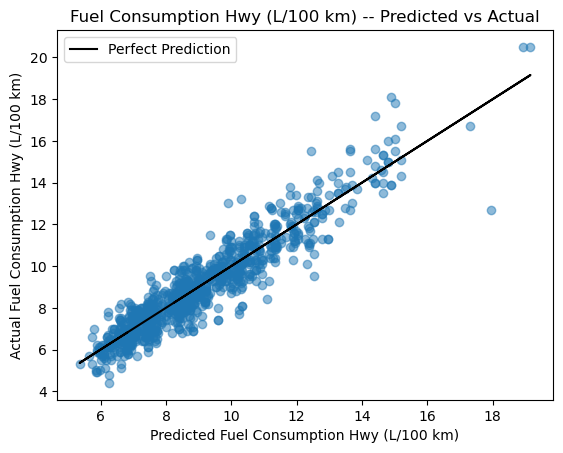

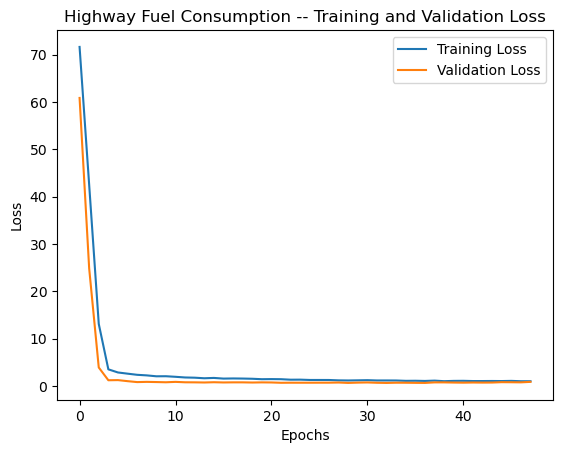

In [ ]:
# Train final model with best hyperparameters
print("\nTraining final Highway model with best hyperparameters...")

# Split training data for validation
X_h_tr, X_h_val, y_h_tr, y_h_val = train_test_split(xh_tr, h_tr, test_size=0.2, random_state=42)

# Convert to tensors and create data loaders
X_h_tr_tensor = torch.FloatTensor(X_h_tr).to(device)
y_h_tr_tensor = torch.FloatTensor(y_h_tr.values).reshape(-1, 1).to(device)
X_h_val_tensor = torch.FloatTensor(X_h_val).to(device)
y_h_val_tensor = torch.FloatTensor(y_h_val.values).reshape(-1, 1).to(device)

train_dataset_h = TensorDataset(X_h_tr_tensor, y_h_tr_tensor)
val_dataset_h = TensorDataset(X_h_val_tensor, y_h_val_tensor)
train_loader_h = DataLoader(train_dataset_h, batch_size=best_params_hwy['batch_size'], shuffle=True)
val_loader_h = DataLoader(val_dataset_h, batch_size=best_params_hwy['batch_size'])

# Create and train model
hwy_model = NeuralNetwork(
    input_size=xh_tr.shape[1],
    n1=best_params_hwy['n1'],
    d1=best_params_hwy['d1'],
    n2=best_params_hwy['n2'],
    d2=best_params_hwy['d2'],
    activation=AF
).to(device)

hwy_model, hwy_train_losses, hwy_val_losses = train_model(
    hwy_model, train_loader_h, val_loader_h, 
    epochs=100, patience=15, lr=best_params_hwy['lr']
)

print("\nHighway Model Training Complete!")

# Plot training history
training_history_plot(hwy_train_losses, hwy_val_losses, 'Highway Fuel Consumption')

# Evaluate on test set
print("\nEvaluating Highway Model on Test Set:")
h_pred = model_evaluation(hwy_model, xh_te, h_te, 'Highway Fuel Consumption')

#### Model Comparison Summary

In [ ]:
# Compare both models side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# City model predictions
city_model.eval()
with torch.no_grad():
    X_c_test_tensor = torch.FloatTensor(xc_te).to(device)
    c_predictions = city_model(X_c_test_tensor).cpu().numpy().flatten()

c_rmse = root_mean_squared_error(c_te, c_predictions)
c_r2 = r2_score(c_te, c_predictions)

axes[0].scatter(c_predictions, c_te, alpha=0.5)
axes[0].plot([c_te.min(), c_te.max()], [c_te.min(), c_te.max()], 'r--', lw=2)
axes[0].set_xlabel('Predicted City Fuel Consumption')
axes[0].set_ylabel('Actual City Fuel Consumption')
axes[0].set_title(f'City Model\nR²={c_r2:.4f}, RMSE={c_rmse:.4f}')
axes[0].grid(True, alpha=0.3)

# Highway model predictions
hwy_model.eval()
with torch.no_grad():
    X_h_test_tensor = torch.FloatTensor(xh_te).to(device)
    h_predictions = hwy_model(X_h_test_tensor).cpu().numpy().flatten()

h_rmse = root_mean_squared_error(h_te, h_predictions)
h_r2 = r2_score(h_te, h_predictions)

axes[1].scatter(h_predictions, h_te, alpha=0.5, color='orange')
axes[1].plot([h_te.min(), h_te.max()], [h_te.min(), h_te.max()], 'r--', lw=2)
axes[1].set_xlabel('Predicted Highway Fuel Consumption')
axes[1].set_ylabel('Actual Highway Fuel Consumption')
axes[1].set_title(f'Highway Model\nR²={h_r2:.4f}, RMSE={h_rmse:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Model':<20} {'R² Score':<15} {'RMSE':<15}")
print("-"*70)
print(f"{'City Consumption':<20} {c_r2:<15.4f} {c_rmse:<15.4f}")
print(f"{'Highway Consumption':<20} {h_r2:<15.4f} {h_rmse:<15.4f}")
print("="*70)

#### Save Models (Optional)

In [ ]:
# Save trained models
torch.save({
    'model_state_dict': city_model.state_dict(),
    'best_params': best_params_city,
    'input_size': xc_tr.shape[1],
    'activation': AF
}, 'city_model.pth')

torch.save({
    'model_state_dict': hwy_model.state_dict(),
    'best_params': best_params_hwy,
    'input_size': xh_tr.shape[1],
    'activation': AF
}, 'hwy_model.pth')

print("Models saved successfully!")
print("- city_model.pth")
print("- hwy_model.pth")

# To load models later:
# checkpoint = torch.load('city_model.pth')
# model = NeuralNetwork(checkpoint['input_size'], checkpoint['best_params']['n1'], ...)
# model.load_state_dict(checkpoint['model_state_dict'])